# 🔥 Stage 3: Supervised Learning with Focal Loss

**Mục tiêu:** Fine-tune RoBERTa trên Kaggle Game Dataset (imbalanced) với Focal Loss

**Dataset:** Kaggle Reddit Gaming Comments (23k samples - giữ nguyên phân phối)

**Method:** Focal Loss để handle class imbalance WITHOUT losing data

---

## 📊 Pipeline:

1. Load Kaggle dataset (imbalanced - giữ nguyên)
2. Implement Focal Loss
3. Fine-tune RoBERTa-Twitter với Custom Trainer
4. Evaluate trên test set
5. Compare với Stage 2 (balanced)

---

## 🎯 **Key Innovation: Focal Loss**

**Formula:** `FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)`

**Benefits:**
- Down-weights easy examples (high confidence)
- Focuses on hard-to-classify samples
- NO data loss (use full 23k dataset)

---

**⚠️ CHẠY TRÊN GOOGLE COLAB**  
Runtime → Change runtime type → T4 GPU

## 📦 Stage 0: Environment Setup

In [ ]:
# Install required packages
!pip install -q transformers torch datasets
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q tqdm

print("✅ Packages installed successfully!")

✅ Packages installed successfully!


In [ ]:
# Import libraries
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All imports successful!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🤖 GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   Device: {torch.cuda.get_device_name(0)}")

✅ All imports successful!
🔥 PyTorch version: 2.8.0+cu126
🤖 GPU available: True
   Device: Tesla T4


## 📥 Stage 1: Load Kaggle Dataset (FULL - Imbalanced)

In [ ]:
# Upload Kaggle dataset
from google.colab import files

print("📤 Please upload your Kaggle CSV file...")
uploaded = files.upload()

# Get filename
csv_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {csv_filename}")

📤 Please upload your Kaggle CSV file...


Saving 23k_r_gaming_comments_sentiments.csv to 23k_r_gaming_comments_sentiments.csv
✅ Uploaded: 23k_r_gaming_comments_sentiments.csv


In [ ]:
# Load dataset (KEEP FULL - IMBALANCED)
df = pd.read_csv(csv_filename)

print("📊 Dataset Info:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {df.columns.tolist()}")
print(f"\n   First 3 rows:")
display(df.head(3))

📊 Dataset Info:
   Shape: (23189, 3)
   Columns: ['Unnamed: 0', 'Comment', 'sentiment']

   First 3 rows:


,Unnamed: 0,Comment,sentiment
0,0,Them: I don't think I like this game.\n\nMe: B...,negative
1,1,Then you leave them to farm the smaller creatu...,negative
2,2,Nothing beats the feeling you get when you see...,positive


📊 CLASS DISTRIBUTION (IMBALANCED - NATURAL)

Using columns: text='text', label='sentiment'

Class counts:
sentiment
positive    10034
neutral      9083
negative     4072
Name: count, dtype: int64

Class percentages:
sentiment
positive    43.270516
neutral     39.169434
negative    17.560050
Name: proportion, dtype: float64

⚖️ Imbalance Ratio: 2.46:1
   Majority class: positive (10034 samples)
   Minority class: negative (4072 samples)


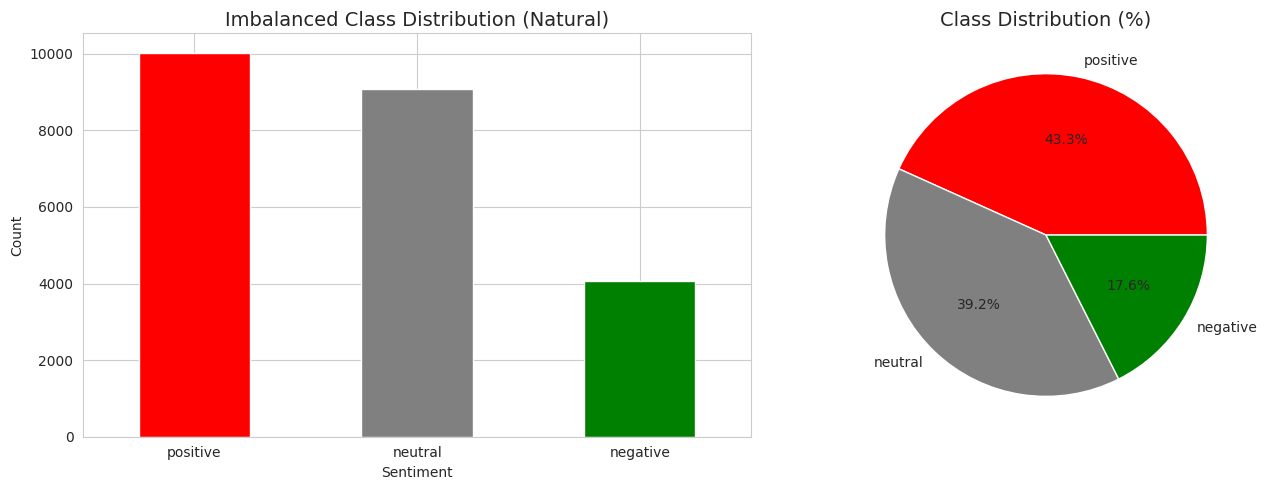


✅ Dataset is IMBALANCED → Will use Focal Loss to handle this!


In [ ]:
# Analyze class distribution (IMBALANCED - KEEP AS IS)
print("="*60)
print("📊 CLASS DISTRIBUTION (IMBALANCED - NATURAL)")
print("="*60)

# Assuming column names
text_col = 'comment' if 'comment' in df.columns else 'text'
label_col = 'sentiment' if 'sentiment' in df.columns else 'label'

print(f"\nUsing columns: text='{text_col}', label='{label_col}'")

print(f"\nClass counts:")
class_counts = df[label_col].value_counts()
print(class_counts)

print(f"\nClass percentages:")
print(df[label_col].value_counts(normalize=True) * 100)

# Calculate imbalance ratio
max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print(f"\n⚖️ Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"   Majority class: {class_counts.idxmax()} ({max_count} samples)")
print(f"   Minority class: {class_counts.idxmin()} ({min_count} samples)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
df[label_col].value_counts().plot(kind='bar', ax=axes[0], color=['red', 'gray', 'green'])
axes[0].set_title('Imbalanced Class Distribution (Natural)', fontsize=14)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df[label_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['red', 'gray', 'green'])
axes[1].set_title('Class Distribution (%)', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✅ Dataset is IMBALANCED → Will use Focal Loss to handle this!")

## 🔥 Stage 2: Focal Loss Implementation

### **What is Focal Loss?**

Focal Loss was introduced in the paper ["Focal Loss for Dense Object Detection"](https://arxiv.org/abs/1708.02002) to address class imbalance.

**Formula:**
```
FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)
```

**Parameters:**
- `α` (alpha): Weighting factor for class balance [0-1]
  - Higher α → More weight on positive class
  - Default: 0.25

- `γ` (gamma): Focusing parameter
  - γ=0 → Standard Cross Entropy
  - γ=2 → Strong focus on hard examples (recommended)
  - Higher γ → More focus on misclassified examples

**How it works:**
- Easy examples (high p_t) → Down-weighted
- Hard examples (low p_t) → Up-weighted
- Minority class gets more attention automatically

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss: Down-weights easy examples, focuses on hard ones

    Args:
        alpha (float): Weighting factor [0-1]. Default: 0.25
        gamma (float): Focusing parameter. Default: 2.0
                      - gamma=0 → Cross Entropy
                      - gamma>0 → Down-weights easy examples
        num_classes (int): Number of classes

    Example:
        >>> focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
        >>> loss = focal_loss(logits, labels)
    """

    def __init__(self, alpha=0.25, gamma=2.0, num_classes=3):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes

    def forward(self, logits, labels):
        """
        Compute focal loss

        Args:
            logits: [batch_size, num_classes] - Model outputs (before softmax)
            labels: [batch_size] - Ground truth class indices

        Returns:
            loss: Scalar focal loss value
        """
        # 1. Compute probabilities
        probs = F.softmax(logits, dim=-1)  # [batch_size, num_classes]

        # 2. Get probability for true class (p_t)
        labels_one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        pt = (probs * labels_one_hot).sum(dim=-1)  # [batch_size]

        # 3. Compute focal weight: (1 - p_t)^gamma
        focal_weight = (1 - pt) ** self.gamma

        # 4. Compute standard cross entropy loss
        ce_loss = F.cross_entropy(logits, labels, reduction='none')

        # 5. Apply focal weight and alpha
        focal_loss = self.alpha * focal_weight * ce_loss

        # 6. Return mean loss
        return focal_loss.mean()


# Test Focal Loss
print("🔥 Testing Focal Loss...")

focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0, num_classes=3)

# Dummy data
dummy_logits = torch.randn(4, 3)  # batch_size=4, num_classes=3
dummy_labels = torch.tensor([0, 1, 2, 1])

loss = focal_loss_fn(dummy_logits, dummy_labels)

print("✅ Focal Loss initialized successfully!")
print(f"   Alpha: {focal_loss_fn.alpha}")
print(f"   Gamma: {focal_loss_fn.gamma}")
print(f"   Test loss: {loss.item():.4f}")

🔥 Testing Focal Loss...
✅ Focal Loss initialized successfully!
   Alpha: 0.25
   Gamma: 2.0
   Test loss: 0.1913


## 🎓 Stage 3: Custom Trainer with Focal Loss

In [ ]:
class FocalLossTrainer(Trainer):
    """
    Custom Trainer that uses Focal Loss instead of Cross Entropy

    Compatible with latest Transformers library (supports num_items_in_batch)

    Usage:
        focal_loss = FocalLoss(alpha=0.25, gamma=2.0)
        trainer = FocalLossTrainer(
            focal_loss_fn=focal_loss,
            model=model,
            args=training_args,
            ...
        )
    """

    def __init__(self, focal_loss_fn, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = focal_loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Override compute_loss to use Focal Loss

        Args:
            model: The model to compute loss for
            inputs: Dictionary with input_ids, attention_mask, labels
            return_outputs: Whether to return model outputs
            num_items_in_batch: Number of items in batch (new in transformers 4.36+)

        Returns:
            loss: Focal loss value
            outputs (optional): Model outputs if return_outputs=True
        """
        # Extract labels from inputs
        labels = inputs.pop("labels")

        # Forward pass through model
        outputs = model(**inputs)
        logits = outputs.logits

        # Compute focal loss using our custom focal loss function
        loss = self.focal_loss_fn(logits, labels)

        # Return loss and outputs if requested
        return (loss, outputs) if return_outputs else loss

print("✅ FocalLossTrainer (v2) defined!")
print("   Compatible with latest Transformers library")
print("   Supports num_items_in_batch parameter")

✅ FocalLossTrainer (v2) defined!
   Compatible with latest Transformers library
   Supports num_items_in_batch parameter


## 🔄 Stage 4: Prepare Dataset

In [ ]:
# Map labels to IDs
unique_labels = sorted(df[label_col].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(f"📋 Label mapping:")
for label, idx in label2id.items():
    print(f"   {label} → {idx}")

# Add numeric labels
df['label'] = df[label_col].map(label2id)

📋 Label mapping:
   negative → 0
   neutral → 1
   positive → 2


In [ ]:
# Train/Val/Test split (70/15/15 - STRATIFIED to preserve imbalance ratio)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['label'],  # Preserve imbalance ratio
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"📊 Dataset split (IMBALANCED - preserved):")
print(f"   Train: {len(train_df)} samples")
print(f"   Val:   {len(val_df)} samples")
print(f"   Test:  {len(test_df)} samples")

print(f"\n⚖️ Imbalance ratio preserved in all splits:")
print(f"\nTrain distribution:")
print(train_df[label_col].value_counts())
print(train_df[label_col].value_counts(normalize=True) * 100)

print(f"\nTest distribution:")
print(test_df[label_col].value_counts())
print(test_df[label_col].value_counts(normalize=True) * 100)

📊 Dataset split (IMBALANCED - preserved):
   Train: 16232 samples
   Val:   3478 samples
   Test:  3479 samples

⚖️ Imbalance ratio preserved in all splits:

Train distribution:
sentiment
positive    7024
neutral     6358
negative    2850
Name: count, dtype: int64
sentiment
positive    43.272548
neutral     39.169542
negative    17.557910
Name: proportion, dtype: float64

Test distribution:
sentiment
positive    1505
neutral     1363
negative     611
Name: count, dtype: int64
sentiment
positive    43.259557
neutral     39.177925
negative    17.562518
Name: proportion, dtype: float64


## 🤖 Stage 5: Load Model & Tokenizer

In [ ]:
# Load tokenizer and model
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

print(f"📥 Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"✅ Model loaded on {device}")
print(f"   Model parameters: {model.num_parameters():,}")

📥 Loading cardiffnlp/twitter-roberta-base-sentiment-latest...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Model loaded on cuda
   Model parameters: 124,647,939


In [ ]:
# Verify column names before tokenization
print("🔍 Verifying column names...")
print(f"   Available columns: {df.columns.tolist()}")
print(f"   Current text_col: '{text_col}'")
print(f"   Current label_col: '{label_col}'")

# Double-check and fix column names if needed
if text_col not in df.columns:
    # Try common text column names
    possible_text_cols = ['comment', 'text', 'content', 'message', 'review']
    text_col = None
    for col in possible_text_cols:
        if col in df.columns:
            text_col = col
            break

    if text_col is None:
        # Use first string column as text column
        for col in df.columns:
            if df[col].dtype == 'object' and col != label_col:
                text_col = col
                break

    print(f"✅ Fixed text_col: '{text_col}'")

if label_col not in df.columns:
    # Try common label column names
    possible_label_cols = ['sentiment', 'label', 'class', 'target']
    label_col = None
    for col in possible_label_cols:
        if col in df.columns:
            label_col = col
            break
    print(f"✅ Fixed label_col: '{label_col}'")

# Verify columns exist
assert text_col in df.columns, f"❌ Text column '{text_col}' not found in {df.columns.tolist()}"
assert label_col in df.columns, f"❌ Label column '{label_col}' not found in {df.columns.tolist()}"

print(f"✅ Using columns: text='{text_col}', label='{label_col}'")

# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(
        examples[text_col],
        truncation=True,
        padding=True,
        max_length=512
    )
# Check if label_id column exists in splits
if 'label_id' not in train_df.columns:
    print("⚠️  label_id not found in splits, creating from label mapping...")
    # Recreate label mapping for splits
    train_df['label_id'] = train_df[label_col].map(label2id)
    val_df['label_id'] = val_df[label_col].map(label2id)
    test_df['label_id'] = test_df[label_col].map(label2id)
    print("✅ label_id created for all splits")


# Convert to HuggingFace Dataset (using label_id instead of label)
train_dataset = Dataset.from_pandas(train_df[[text_col, 'label_id']].rename(columns={'label_id': 'label'}))
val_dataset = Dataset.from_pandas(val_df[[text_col, 'label_id']].rename(columns={'label_id': 'label'}))
test_dataset = Dataset.from_pandas(test_df[[text_col, 'label_id']].rename(columns={'label_id': 'label'}))

# Tokenize
print("🔄 Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

print("✅ Tokenization complete!")
print(f"   Train samples: {len(train_dataset)}")
print(f"   Val samples: {len(val_dataset)}")
print(f"   Test samples: {len(test_dataset)}")

🔍 Verifying column names...
   Available columns: ['Unnamed: 0', 'Comment', 'sentiment', 'label']
   Current text_col: 'text'
   Current label_col: 'sentiment'
✅ Fixed text_col: 'Comment'
✅ Using columns: text='Comment', label='sentiment'
⚠️  label_id not found in splits, creating from label mapping...
✅ label_id created for all splits
🔄 Tokenizing datasets...


Map:   0%|          | 0/16232 [00:00<?, ? examples/s]

Map:   0%|          | 0/3478 [00:00<?, ? examples/s]

Map:   0%|          | 0/3479 [00:00<?, ? examples/s]

✅ Tokenization complete!
   Train samples: 16232
   Val samples: 3478
   Test samples: 3479


## 🔥 Stage 6: Training with Focal Loss

In [ ]:
# Training arguments
training_args = TrainingArguments(
    output_dir='./stage3_roberta_focal_loss',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
)

print("✅ Training arguments configured")
print(f"   Epochs: {training_args.num_train_epochs}")
print(f"   Batch size (train): {training_args.per_device_train_batch_size}")
print(f"   Learning rate: {training_args.learning_rate}")

✅ Training arguments configured
   Epochs: 3
   Batch size (train): 16
   Learning rate: 2e-05


In [ ]:
# Initialize Focal Loss
focal_loss_fn = FocalLoss(
    alpha=0.25,      # Weighting factor
    gamma=2.0,       # Focusing parameter (standard value)
    num_classes=3
)

print("🔥 Focal Loss configured:")
print(f"   Alpha: {focal_loss_fn.alpha}")
print(f"   Gamma: {focal_loss_fn.gamma}")
print(f"   Num classes: {focal_loss_fn.num_classes}")

🔥 Focal Loss configured:
   Alpha: 0.25
   Gamma: 2.0
   Num classes: 3


In [ ]:
# Initialize Custom Trainer with Focal Loss
trainer = FocalLossTrainer(
    focal_loss_fn=focal_loss_fn,  # Use Focal Loss
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer)
)

print("✅ FocalLossTrainer initialized")
print("   Using Focal Loss instead of Cross Entropy!")

✅ FocalLossTrainer initialized
   Using Focal Loss instead of Cross Entropy!


In [ ]:
# Train!
print("="*60)
print("🔥 STARTING TRAINING (STAGE 3 - FOCAL LOSS)")
print("="*60)
print(f"   Method: Focal Loss (α={focal_loss_fn.alpha}, γ={focal_loss_fn.gamma})")
print(f"   Dataset: Imbalanced (FULL {len(train_df)} samples)")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")
print(f"   Estimated time: ~90-120 minutes on T4 GPU")
print("="*60)

train_result = trainer.train()

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"   Final loss: {train_result.training_loss:.4f}")
print(f"   Total time: {train_result.metrics['train_runtime']:.2f}s")

🔥 STARTING TRAINING (STAGE 3 - FOCAL LOSS)
   Method: Focal Loss (α=0.25, γ=2.0)
   Dataset: Imbalanced (FULL 16232 samples)
   Training samples: 16232
   Validation samples: 3478
   Estimated time: ~90-120 minutes on T4 GPU


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: thanhcongaptx48 (thanhcongaptx48-hcmc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
200,0.074800,0.066148
400,0.062100,0.053806
600,0.056100,0.049328


Step,Training Loss,Validation Loss
200,0.074800,0.066148
400,0.062100,0.053806
600,0.056100,0.049328
800,0.048800,0.043075
1000,0.052300,0.039207
1200,0.030500,0.043543
1400,0.032800,0.043371
1600,0.026600,0.039074
1800,0.034600,0.036892
2000,0.032400,0.037662



✅ TRAINING COMPLETE!
   Final loss: 0.0374
   Total time: 6515.64s


## 📊 Stage 7: Evaluation

In [ ]:
# Predict on test set
print("🔮 Predicting on test set...")

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

# Convert to labels
pred_labels = [id2label[p] for p in preds]
true_labels = test_df[label_col].tolist()

print("✅ Predictions complete!")

🔮 Predicting on test set...


✅ Predictions complete!


In [ ]:
# Calculate metrics
acc = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average='weighted')

print("="*60)
print("🔥 STAGE 3 RESULTS (FOCAL LOSS - IMBALANCED)")
print("="*60)
print(f"\n✅ Overall Metrics:")
print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"   F1-Score:  {f1:.4f}")

print(f"\n📋 Per-class Performance:")
print(classification_report(true_labels, pred_labels, digits=4))

🔥 STAGE 3 RESULTS (FOCAL LOSS - IMBALANCED)

✅ Overall Metrics:
   Accuracy:  0.8675 (86.75%)
   F1-Score:  0.8684

📋 Per-class Performance:
              precision    recall  f1-score   support

    negative     0.7489    0.8740    0.8066       611
     neutral     0.8920    0.8364    0.8633      1363
    positive     0.9032    0.8930    0.8981      1505

    accuracy                         0.8675      3479
   macro avg     0.8481    0.8678    0.8560      3479
weighted avg     0.8717    0.8675    0.8684      3479



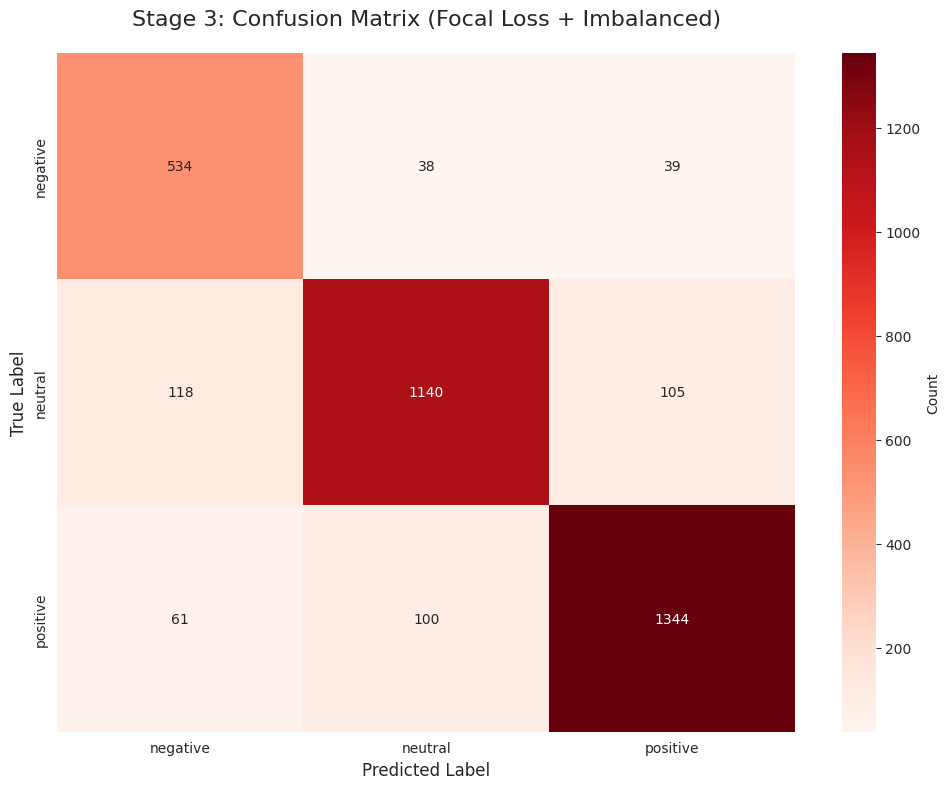


📈 Per-class Accuracy:
   negative  : 0.8740 (87.40%)
   neutral   : 0.8364 (83.64%)
   positive  : 0.8930 (89.30%)


In [ ]:
# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=unique_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=unique_labels,
    yticklabels=unique_labels,
    cbar_kws={'label': 'Count'}
)
plt.title('Stage 3: Confusion Matrix (Focal Loss + Imbalanced)', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\n📈 Per-class Accuracy:")
for i, label in enumerate(unique_labels):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"   {label:10s}: {class_acc:.4f} ({class_acc*100:.2f}%)")

## 💾 Stage 8: Save Results & Model

In [ ]:
# Save results to JSON
results = {
    'stage': 3,
    'method': 'Supervised Learning (Focal Loss + Imbalanced)',
    'dataset': 'Kaggle Game Reviews',
    'loss_function': 'Focal Loss',
    'focal_loss_params': {
        'alpha': focal_loss_fn.alpha,
        'gamma': focal_loss_fn.gamma
    },
    'dataset_size': len(df),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'model': MODEL_NAME,
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'learning_rate': training_args.learning_rate,
    'metrics': {
        'accuracy': float(acc),
        'f1_weighted': float(f1),
    },
    'class_distribution': df[label_col].value_counts().to_dict(),
    'imbalance_ratio': float(imbalance_ratio),
    'training_time_seconds': train_result.metrics['train_runtime']
}

with open('stage3_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("💾 Results saved to: stage3_results.json")

💾 Results saved to: stage3_results.json


In [ ]:
# Save model & tokenizer
model_path = './stage3_roberta_focal_loss_final'

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"💾 Model saved to: {model_path}")
print("\n✅ Stage 3 complete!")

💾 Model saved to: ./stage3_roberta_focal_loss_final

✅ Stage 3 complete!


In [ ]:
# Download files from Colab
from google.colab import files

print("📥 Downloading results...")
files.download('stage3_results.json')

print("\n✅ All done! Stage 3 complete.")

📥 Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All done! Stage 3 complete.


---

# 🎯 **SUMMARY**


1. Loaded Kaggle game dataset (FULL - imbalanced)
2. Implemented Focal Loss (α=0.25, γ=2.0)
3. Created Custom Trainer with Focal Loss
4. Fine-tuned RoBERTa on imbalanced data
5. Evaluated on test set
6. Saved model & results


## 🔜 **Next Steps:**

- **Stage 4:** Compare all 3 stages
  - Stage 1: Weak Supervision (Reddit)
  - Stage 2: Supervised (Balanced)
  - Stage 3: Supervised (Focal Loss) ⭐

---